<a href="https://colab.research.google.com/github/Harsha-1220/Harsha-1220/blob/main/Zomato_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install kagglehub


In [10]:
import kagglehub
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'zomato-bangalore-restaurants' dataset.
Path to dataset files: /kaggle/input/zomato-bangalore-restaurants


In [11]:
import os


files_list = os.listdir(path)
print("Files in dataset:", files_list)

Files in dataset: ['zomato.csv']


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [13]:

print(df.info())


print("\nMissing values:\n", df.isnull().sum())


print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [21]:
df_clean = df.drop(columns=['url', 'address', 'phone', 'menu_item', 'reviews_list', 'dish_liked'])

def clean_rate(value):
    if pd.isnull(value):
        return None
    value = str(value).split('/')[0].strip()
    if value in ['NEW', '-']:
        return None
    try:
        return float(value)
    except:
        return None

df_clean['rate'] = df_clean['rate'].apply(clean_rate)

df_clean['approx_cost(for two people)'] = (
    df_clean['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)
df_clean['approx_cost(for two people)'] = pd.to_numeric(
    df_clean['approx_cost(for two people)'], errors='coerce'
)

df_clean = df_clean.dropna(subset=['rate'])

df_clean['approx_cost(for two people)'] = df_clean['approx_cost(for two people)'].fillna(
    df_clean['approx_cost(for two people)'].median()
)

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("New shape:", df_clean.shape)
df_clean.head()

New shape: (41665, 11)


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


In [22]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

df_model['online_order'] = df_model['online_order'].map({'Yes': 1, 'No': 0})
df_model['book_table'] = df_model['book_table'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
categorical_cols = ['location', 'rest_type', 'cuisines', 'listed_in(type)', 'listed_in(city)']

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['name', 'rate'])
y = df_model['rate']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (41665, 9)
y shape: (41665,)


,online_order,book_table,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,1,1,775,1,24,1908,800.0,0,1
1,1,0,787,1,24,820,800.0,0,1
2,1,0,918,1,19,657,800.0,0,1
3,0,0,88,1,73,2236,300.0,0,1
4,0,0,166,4,24,1935,600.0,0,1


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.9247536272096888
RMSE: 0.12065396380497358


/tmp/ipykernel_771/3512434116.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


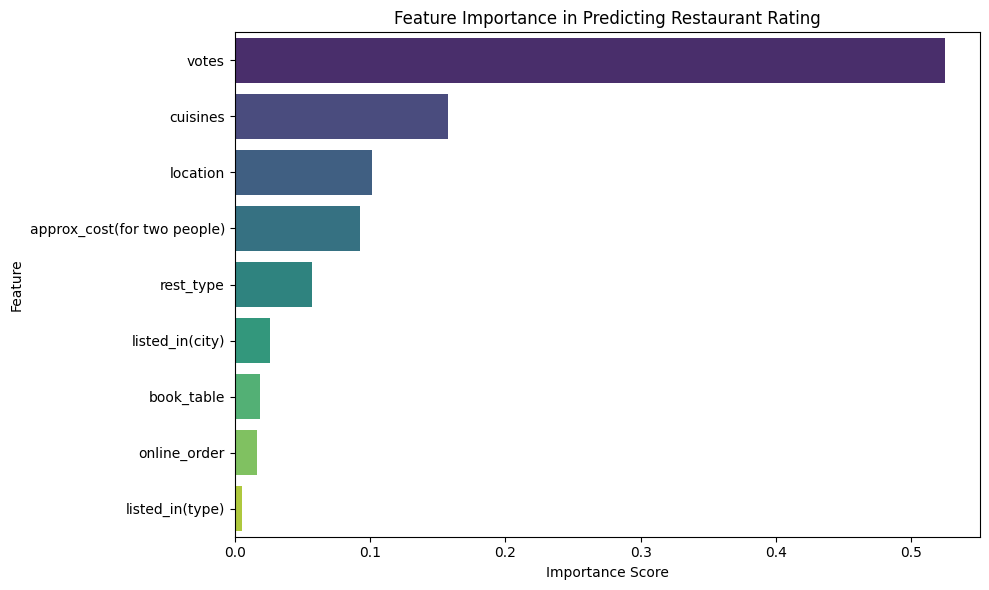

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Feature Importance in Predicting Restaurant Rating')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()